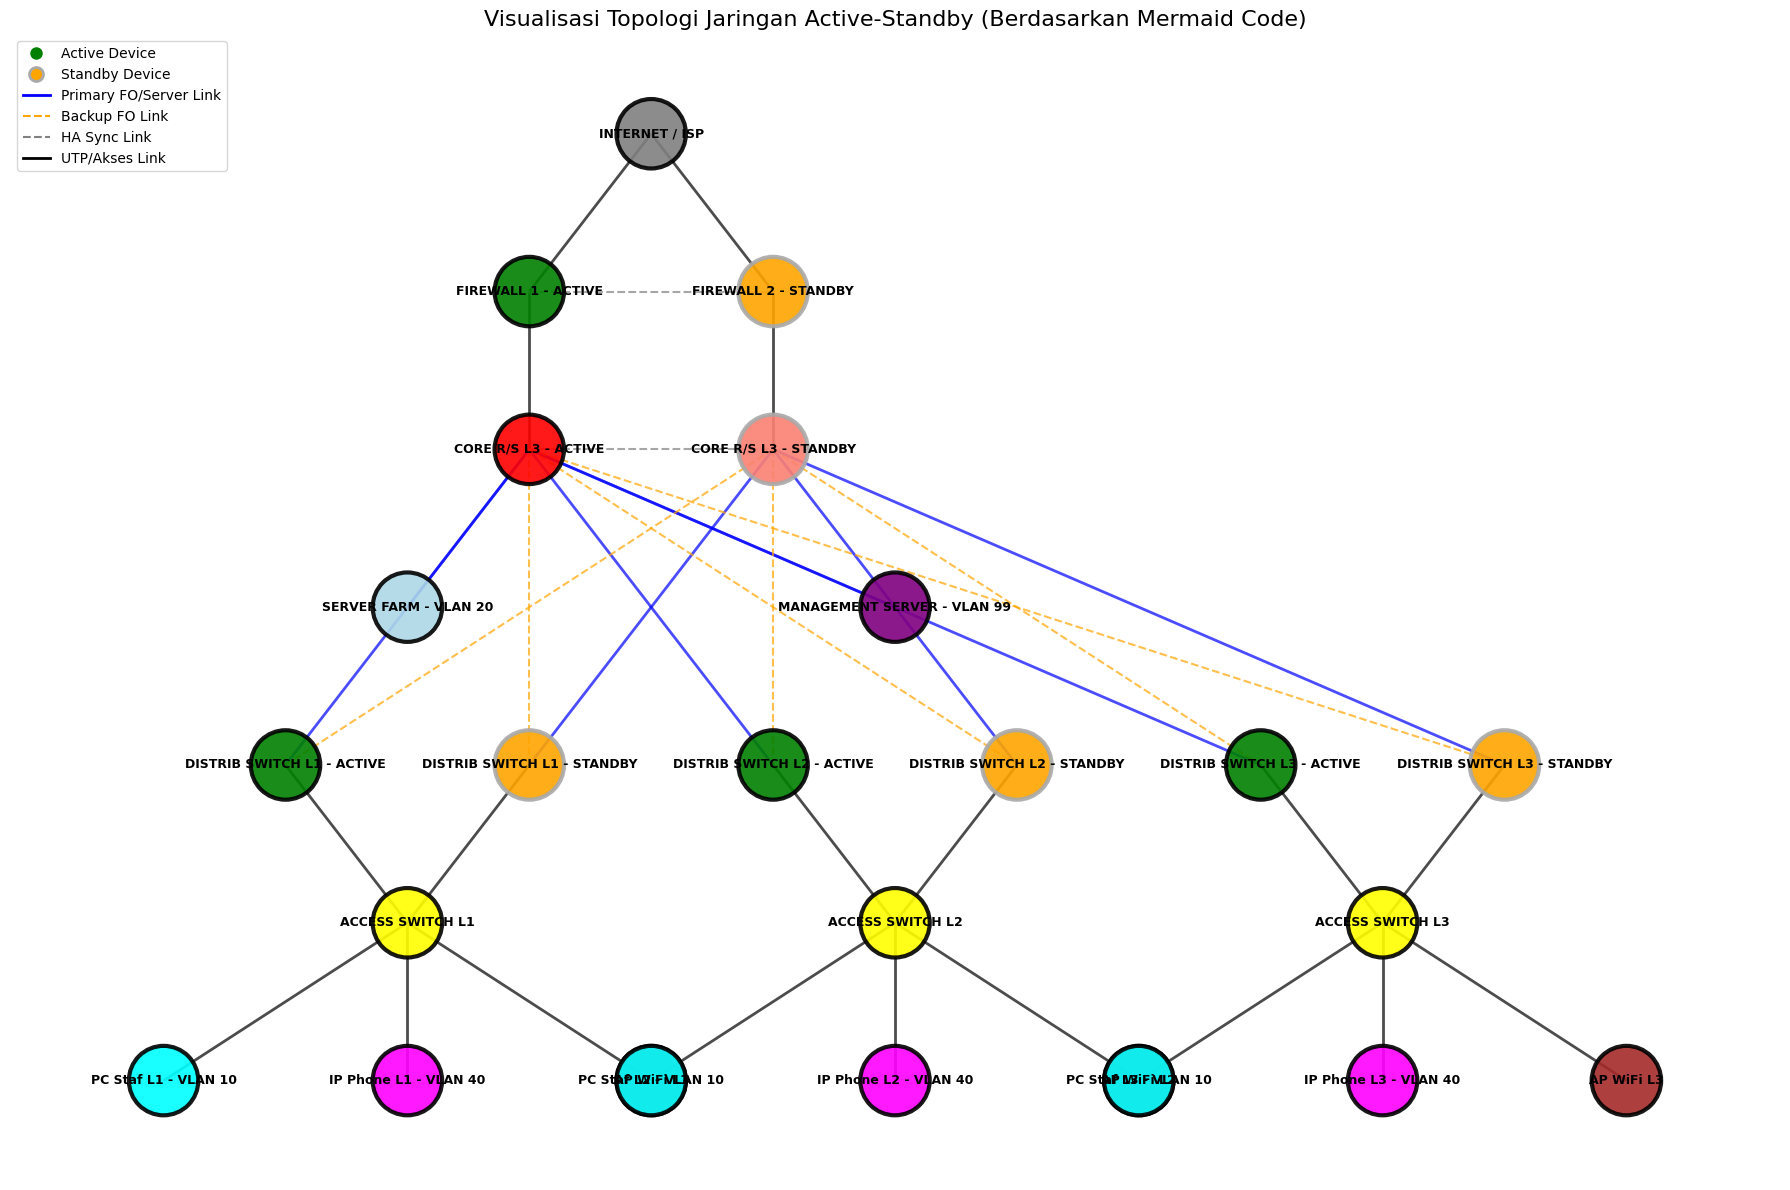

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. INISIALISASI GRAFIK DAN NODE ---
G = nx.Graph()

# Definisi Node dan Atribut
nodes_data = {
    # L1: RUANG SERVER & CORE
    "A": {"label": "INTERNET / ISP", "layer": 0, "color": "gray", "style": "solid"},
    "B1": {"label": "FIREWALL 1 - ACTIVE", "layer": 1, "color": "green", "style": "solid"},
    "B2": {"label": "FIREWALL 2 - STANDBY", "layer": 1, "color": "orange", "style": "dashed"},
    "C1": {"label": "CORE R/S L3 - ACTIVE", "layer": 2, "color": "red", "style": "solid"},
    "C2": {"label": "CORE R/S L3 - STANDBY", "layer": 2, "color": "salmon", "style": "dashed"},
    "D": {"label": "SERVER FARM - VLAN 20", "layer": 3, "color": "lightblue", "style": "solid"},
    "E": {"label": "MANAGEMENT SERVER - VLAN 99", "layer": 3, "color": "purple", "style": "solid"},

    # L1: AREA KERJA & DISTRIBUTION
    "F1": {"label": "DISTRIB SWITCH L1 - ACTIVE", "layer": 4, "color": "green", "style": "solid"},
    "F2": {"label": "DISTRIB SWITCH L1 - STANDBY", "layer": 4, "color": "orange", "style": "dashed"},
    "AS1": {"label": "ACCESS SWITCH L1", "layer": 5, "color": "yellow", "style": "solid"},
    "PC1": {"label": "PC Staf L1 - VLAN 10", "layer": 6, "color": "cyan", "style": "solid"},
    "IPP1": {"label": "IP Phone L1 - VLAN 40", "layer": 6, "color": "magenta", "style": "solid"},
    "AP1": {"label": "AP WiFi L1", "layer": 6, "color": "brown", "style": "solid"},

    # L2: AREA KERJA & DISTRIBUTION
    "G1": {"label": "DISTRIB SWITCH L2 - ACTIVE", "layer": 4, "color": "green", "style": "solid"},
    "G2": {"label": "DISTRIB SWITCH L2 - STANDBY", "layer": 4, "color": "orange", "style": "dashed"},
    "AS2": {"label": "ACCESS SWITCH L2", "layer": 5, "color": "yellow", "style": "solid"},
    "PC2": {"label": "PC Staf L2 - VLAN 10", "layer": 6, "color": "cyan", "style": "solid"},
    "IPP2": {"label": "IP Phone L2 - VLAN 40", "layer": 6, "color": "magenta", "style": "solid"},
    "AP2": {"label": "AP WiFi L2", "layer": 6, "color": "brown", "style": "solid"},

    # L3: AREA KERJA & DISTRIBUTION
    "H1": {"label": "DISTRIB SWITCH L3 - ACTIVE", "layer": 4, "color": "green", "style": "solid"},
    "H2": {"label": "DISTRIB SWITCH L3 - STANDBY", "layer": 4, "color": "orange", "style": "dashed"},
    "AS3": {"label": "ACCESS SWITCH L3", "layer": 5, "color": "yellow", "style": "solid"},
    "PC3": {"label": "PC Staf L3 - VLAN 10", "layer": 6, "color": "cyan", "style": "solid"},
    "IPP3": {"label": "IP Phone L3 - VLAN 40", "layer": 6, "color": "magenta", "style": "solid"},
    "AP3": {"label": "AP WiFi L3", "layer": 6, "color": "brown", "style": "solid"},
}

for node, data in nodes_data.items():
    G.add_node(node, **data)

# --- 2. DEFINISI EDGE (KONEKSI) ---
# Format: (u, v, description, style, color)
edges_data = [
    # Core Layer Connections
    ("A", "B1", "ISP Link", "solid", "black"),
    ("A", "B2", "ISP Link", "solid", "black"),
    ("B1", "C1", "Link", "solid", "black"),
    ("B2", "C2", "Link", "solid", "black"),
    ("B1", "B2", "HA Sync", "dashed", "gray"),
    ("C1", "C2", "HA Sync", "dashed", "gray"),
    ("C1", "D", "Server Link", "solid", "blue"),
    ("C1", "E", "Mgmt Link", "solid", "blue"),

    # Core ke Distrib L1 (Primary & Backup FO)
    ("C1", "F1", "Primary FO", "solid", "blue"),
    ("C1", "F2", "Backup FO", "dashed", "orange"),
    ("C2", "F2", "Primary FO", "solid", "blue"),
    ("C2", "F1", "Backup FO", "dashed", "orange"),

    # Core ke Distrib L2 (Primary & Backup FO)
    ("C1", "G1", "Primary FO", "solid", "blue"),
    ("C1", "G2", "Backup FO", "dashed", "orange"),
    ("C2", "G2", "Primary FO", "solid", "blue"),
    ("C2", "G1", "Backup FO", "dashed", "orange"),

    # Core ke Distrib L3 (Primary & Backup FO)
    ("C1", "H1", "Primary FO", "solid", "blue"),
    ("C1", "H2", "Backup FO", "dashed", "orange"),
    ("C2", "H2", "Primary FO", "solid", "blue"),
    ("C2", "H1", "Backup FO", "dashed", "orange"),

    # Distrib ke Access dan End Devices L1
    ("F1", "AS1", "UTP Cat6", "solid", "black"),
    ("F2", "AS1", "UTP Cat6", "solid", "black"), # Redundant Link
    ("AS1", "PC1", "Access", "solid", "black"),
    ("AS1", "IPP1", "Access", "solid", "black"),
    ("AS1", "AP1", "Access", "solid", "black"),

    # Distrib ke Access dan End Devices L2
    ("G1", "AS2", "UTP Cat6", "solid", "black"),
    ("G2", "AS2", "UTP Cat6", "solid", "black"),
    ("AS2", "PC2", "Access", "solid", "black"),
    ("AS2", "IPP2", "Access", "solid", "black"),
    ("AS2", "AP2", "Access", "solid", "black"),

    # Distrib ke Access dan End Devices L3
    ("H1", "AS3", "UTP Cat6", "solid", "black"),
    ("H2", "AS3", "UTP Cat6", "solid", "black"),
    ("AS3", "PC3", "Access", "solid", "black"),
    ("AS3", "IPP3", "Access", "solid", "black"),
    ("AS3", "AP3", "Access", "solid", "black"),
]

for u, v, description, style, color in edges_data:
    G.add_edge(u, v, label=description, style=style, color=color)

# --- 3. VISUALISASI MENGGUNAKAN MATPLOTLIB & NETWORKX ---

plt.figure(figsize=(18, 12))

# Tentukan posisi node (Layout berjenjang berdasarkan 'layer')
# Kita gunakan posisi manual berdasarkan 'layer'
pos = {}
# Menentukan posisi Y untuk setiap layer
layer_y = {
    0: 7, 1: 6, 2: 5, 3: 4, 4: 3, 5: 2, 6: 1
}
# Menentukan posisi X secara horizontal
x_pos_map = {
    "A": 0, "B1": -1, "B2": 1, "C1": -1, "C2": 1, "D": -2, "E": 2, # Core
    "F1": -3, "F2": -1, "AS1": -2, "PC1": -4, "IPP1": -2, "AP1": 0, # L1
    "G1": 1, "G2": 3, "AS2": 2, "PC2": 0, "IPP2": 2, "AP2": 4, # L2
    "H1": 5, "H2": 7, "AS3": 6, "PC3": 4, "IPP3": 6, "AP3": 8, # L3
}

for node, data in G.nodes(data=True):
    pos[node] = (x_pos_map.get(node, 0), layer_y.get(data['layer'], 0))


# Ekstraksi Atribut Node untuk Plotting
node_labels = nx.get_node_attributes(G, 'label')
node_colors = [G.nodes[n]['color'] for n in G.nodes()]
node_edge_styles = [G.nodes[n]['style'] for n in G.nodes()]
node_edge_colors = [('black' if G.nodes[n]['style'] == 'solid' else 'darkgray') for n in G.nodes()]

# Ekstraksi Atribut Edge untuk Plotting
edge_colors = [G.edges[u, v]['color'] for u, v in G.edges()]
edge_styles = [G.edges[u, v]['style'] for u, v in G.edges()]
edge_labels = nx.get_edge_attributes(G, 'label')

# 3.1 Gambar Node
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9,
                       edgecolors=node_edge_colors, linewidths=3)

# 3.2 Gambar Edge (Garis)
# Memisahkan edge berdasarkan gaya (solid/dashed) untuk visualisasi yang lebih baik
solid_edges = [(u, v) for u, v, d in G.edges(data=True) if d['style'] == 'solid']
dashed_edges = [(u, v) for u, v, d in G.edges(data=True) if d['style'] == 'dashed']

# Solid Edges
nx.draw_networkx_edges(G, pos, edgelist=solid_edges, width=2, alpha=0.7,
                       edge_color=[G.edges[u, v]['color'] for u, v in solid_edges],
                       style='solid')

# Dashed Edges
nx.draw_networkx_edges(G, pos, edgelist=dashed_edges, width=1.5, alpha=0.7,
                       edge_color=[G.edges[u, v]['color'] for u, v in dashed_edges],
                       style='dashed', )


# 3.3 Gambar Label Node
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

# 3.4 Gambar Label Edge (Keterangan koneksi, opsional karena padat)
# edge_pos = nx.spring_layout(G) # Atau layout lain
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

# 3.5 Pengaturan Plot
plt.title("Visualisasi Topologi Jaringan Active-Standby (Berdasarkan Mermaid Code)", fontsize=16)
plt.axis('off') # Sembunyikan sumbu

# Legend Sederhana (Node)
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Active Device', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Standby Device', markerfacecolor='orange', markersize=10, linestyle='dashed', markeredgecolor='darkgray', markeredgewidth=2),
    plt.Line2D([0], [0], color='blue', lw=2, label='Primary FO/Server Link'),
    plt.Line2D([0], [0], color='orange', lw=1.5, linestyle='--', label='Backup FO Link'),
    plt.Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label='HA Sync Link'),
    plt.Line2D([0], [0], color='black', lw=2, label='UTP/Akses Link'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()